In [1]:
import sys

In [2]:
# Install relevant python libraries
!{sys.executable} -m pip install setuptools

In [3]:
import numpy as np
import pandas as pd

In [4]:
pd.options.display.max_columns = None
# pd.options.display.max_rows = None

# Creating a Training Set
In order to effectively process the data, we will need to standardise the data (i.e. address NaN values which would raise errors in processing) and create a training set that focuses on predicting the future onset of sepsis after a certain window.

In [5]:
import torch
from torch.utils.data import Dataset, DataLoader
import json
from concurrent.futures import ProcessPoolExecutor
from pathlib import Path

In [7]:
class DataPreprocessor:

    home_dir = Path.home()
    baseline_dir = home_dir / "sepsis_prediction_project" / "baselines.json"

    # Load baseline values stored in external JSON file
    with open(str(baseline_dir), mode="r", encoding="utf-8") as baselines_file:
        baselines = json.load(baselines_file)

    @classmethod
    def preprocessing(cls, df: pd.DataFrame, hours_ahead: int) -> pd.DataFrame:

        # Forward fill to remove NaN values, replacing them with the last reading recorded (assuming it has not changed since)      
        df = df.ffill()

        # Replace remaining NaN values with baseline "healthy" values
        row_indices, col_indices = np.where(df.isna())

        for row_index, col_index in zip(row_indices ,col_indices):
            baseline = df.columns[col_index]

            if baseline in cls.baselines:
                df.iloc[row_index, col_index] = cls.baselines[baseline]

        # Add target labels to the data and remove additional records after the first target onset of sepsis

        target_series = df["SepsisLabel"].shift(-hours_ahead)
        df["Target"] = target_series.ffill().fillna(0).astype(int)

        # first_onset = df.loc[df["SepsisLabel"] == 1].iloc[[0]]
        # df.drop(df[df["SepsisLabel"] == 1].index, inplace=True)
        # pd.concat([df, first_onset], ignore_index=0) 

        sepsis_indices = df.index[df["SepsisLabel"] == 1].to_list()

        if sepsis_indices:
            first_onset_index = sepsis_indices[0]
            df = df.iloc[: first_onset_index + 1].copy()

        return df

    # Saving a single file as a pytorch tensor
    @staticmethod
    def process_single_file(file_args: tuple) -> bool:
    
        input_path, output_dir, overwrite = file_args
        output_path = output_dir / f"{input_path.stem}.pt"
    
        # If the file has already been cleaned and converted and we do not want to overwrite, avoid wasting time reprocessing the file
        if output_path.exists() and not overwrite:
            return True

        try:
            # Clean the chosen file
            df = pd.read_csv(input_path, sep="|")
            df_cleaned = DataPreprocessor.preprocessing(df=df, hours_ahead=12)
    
            # Separate the data into the input features and target outputs
            input_features = df_cleaned.drop(columns=["SepsisLabel", "Target"]).to_numpy()
            target_outputs = df_cleaned[["Target"]].to_numpy()
    
            input_tensor = torch.from_numpy(input_features).float()
            target_tensor = torch.from_numpy(target_outputs).float()
    
            # Save the tensors in a dictionary alongside some metadata
            torch.save({"x": input_tensor, "y": target_tensor, "patient_id": input_path.stem}, output_path)
            return True

        except Exception as e:
            print(f"Failed to process file {input_path.name}: {e}")

            # If the file is partially written, delete the corrupted file
            if output_path.exists():
                output_path.unlink()
                
            return False

    @staticmethod
    def batch_process_files(input_dir: str, output_dir: str, overwrite: bool, max_workers: int) -> bool:

        # Convert directory strings into Path objects
        input_dir = Path(input_dir)
        output_dir = Path(output_dir)

        # If the output directory does not exist, create a new directory
        output_dir.mkdir(parents=True, exist_ok=True)

        # Return a list of all the .psv files in the input directory to iterate through
        input_files = sorted(input_dir.glob("*.psv"))
        
        # Generate input tuples to feed into the process_single_file function
        file_args = [(input_path, output_dir, overwrite) for input_path in input_files]

        # Parallelise the process_single_file function across the max cores available (max_workers)
        
        with ProcessPoolExecutor(max_workers=max_workers) as executor:
            conversion_success = executor.map(DataPreprocessor.process_single_file, file_args)

        for success in conversion_success:

            if not success:
                print("A file failed to process")
                return False

        return True
                
            
        

In [8]:
from torch.utils.data import Dataset

In [9]:
# Dataset class to enable batch processing of tensors via torch.utils.data.DataLoader
class SepsisDataset(Dataset):

    def __init__(self, input_dir: str) -> None:
        self.input_dir = Path(input_dir)
        self.input_files = sorted(self.input_dir.glob("*.pt"))

    # Returns number of files
    def __len__(self) -> int:
        return len(self.input_files)

    # Returns a single tensor
    def __getitem__(self, index: int) -> tuple:
        file_path = self.input_files[index]

        # Load the tensor dictionary stored and return the feature and target stored
        data = torch.load(file_path)
        return data["x"], data["y"]
        
        

# Creating the Neural Network
Now that we have the data preprocessed, we can now work on the machine learning model to process this data. We will be using tensorflow to create the model.

In [62]:
df = pd.read_csv("/Users/felix/physionet.org/files/challenge-2019/1.0.0/training/training_setA/p000001.psv", sep="|")
len(df.columns)


41

In [63]:
import torch
import torch.nn as nn
import torch.optim as optim

In [64]:
# Creating the neural network
class NeuralNetwork(nn.Module):

    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(41, 32),           # n.b. the Linear function is the linear regression function wx + b
            nn.Sigmoid(),                # Here it compresses the input tensor size of size 41 into an output tensor of size 32
            nn.Linear(32, 4),
            nn.Sigmoid(),
            nn.Linear(4, 1),
            nn.Sigmoid()
        )

    def forward_prop(self, x):
        return self.model

In [65]:
# Instantiating the model
SepsisNN = NeuralNetwork()

In [66]:
# Setup pytorch dataset with tensors
home_dir = Path.home()
input_dir = home_dir / "sepsis_training_files"
DataSet = SepsisDataset(input_dir)

In [67]:
# Setup dataloader
DataLoaderInstance = DataLoader(DataSet, batch_size=32, shuffle=True)

In [68]:
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence

In [ ]:
# Ensure that all tensors in the torch.stack of the dataloader is of the same size to avoid dimension error
def padding(batch_list: list) -> tuple:

    # Separate the features from the labels for each patient in the batch
    batch_features = [patient[0] for patient in batch_list]
    batch_labels = [patient[1] for patient in batch_list]

    # Calculate the number of patient records for each patient in the batch to get original data back after padding
    lengths = torch.tensor([len(feature) for feature in batch_features], dtype=torch.long)

    # Add redundant 0.0 values to ensure each tensor has the same dimension
    padded_features = pad_sequence(batch_features, batch_first=True, padding_value=0.0)
    # padded_labels = pad_sequence(batch_labels, batch_first=True, padding_value=0.0)

    patient_labels = torch.tensor([
        1.0 if (torch.tensor(l) == 1).any() else 0.0 for l in batch_labels
    ], dtype=torch.float32)

    return padded_features, patient_labels, lengths

In [71]:
pd.read_csv("/Users/felix/physionet.org/files/challenge-2019/1.0.0/training/training_setA/p013003.psv", sep="|")

,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,FiO2,pH,PaCO2,SaO2,AST,BUN,Alkalinephos,Calcium,Chloride,Creatinine,Bilirubin_direct,Glucose,Lactate,Magnesium,Phosphate,Potassium,Bilirubin_total,TroponinI,Hct,Hgb,PTT,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,82.79,0,NaN,NaN,-74.86,1,1
1,128.0,99.0,38.33,85.0,63.67,NaN,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,82.79,0,NaN,NaN,-74.86,2,1
2,127.0,100.0,NaN,108.0,70.67,NaN,18.5,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,82.79,0,NaN,NaN,-74.86,3,1
3,115.0,100.0,NaN,99.0,61.67,NaN,17.0,NaN,NaN,NaN,0.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,82.79,0,NaN,NaN,-74.86,4,1
4,111.0,100.0,NaN,96.0,54.00,NaN,14.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,82.79,0,NaN,NaN,-74.86,5,1
5,106.0,100.0,NaN,92.0,56.67,NaN,17.5,NaN,NaN,NaN,0.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,82.79,0,NaN,NaN,-74.86,6,1
6,108.0,100.0,38.33,103.0,62.33,NaN,18.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,82.79,0,NaN,NaN,-74.86,7,1
7,112.0,100.0,NaN,119.0,73.67,NaN,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,82.79,0,NaN,NaN,-74.86,8,1


In [105]:
DataLoaderInstance = DataLoader(DataSet, 
                                batch_size=32, 
                                shuffle=True,
                                collate_fn=padding)

In [114]:
# Create LSTM
"""
Talk about LSTM model & theory 
pass input 
"""

class PredictionModel(nn.Module):

    def __init__(self) -> None:
        super().__init__()
        self.lstm = nn.LSTM(input_size=40, hidden_size=64, num_layers=1, batch_first=True)
        self.fc1 = nn.Linear(in_features=64, out_features=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        """
            Pack padded tensors to remove redundant data, compressing tensors in each batch into a 1D array alongside
            the original tensor size so the computer can correctly "decompress" the input data
        """
        x_packed = pack_padded_sequence(input=x, lengths=lengths.cpu(), batch_first=True, enforce_sorted=False)

        h_n_collection, (h_n, c_n) = self.lstm(x_packed)
        out = h_n[-1]
        out = self.fc1(out)
        out = self.sigmoid(out)

        return out

In [ ]:
SepsisModel = PredictionModel()
loss_function = nn.BCELoss()
optimiser = optim.Adam(SepsisModel.parameters(), lr=0.001)

In [112]:
# Use GPU if available, else fall back to CPU usage and moves all model weights, params and buffers onto selected hardware
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SepsisModel.to(device)

PredictionModel(
  (lstm): LSTM(40, 64, batch_first=True)
  (fc1): Linear(in_features=64, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

In [ ]:
# Train the LSTM Model

num_epochs = 50
loss_history = []

for epoch in range(num_epochs):
    # Sets the model in training mode
    SepsisModel.train()
    running_loss = 0.0

    # Iterate through each batch in the data loader
    for i, (features, labels, lengths) in enumerate(DataLoaderInstance):
        # Load features and labels onto the dedicated hardware device
        features, labels = features.to(device), labels.to(device).float()

        #

        # print(features)
        # Forward propogate through the model and calculate the loss
        outputs = SepsisModel(features, lengths)
        # print(outputs.squeeze(-1))
        # print(labels.squeeze(-1))
        loss = loss_function(outputs.squeeze(-1), labels.squeeze(-1))

        # Backpropogate through the model to update the weights and biases in the model
        optimiser.zero_grad()
        loss.backward()
        optimiser.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss / len(DataLoaderInstance):.4f}")
    loss_history.append(loss)

/var/folders/pr/nbl3fd0122gbx35rg3wkljth0000gn/T/ipykernel_34104/194540466.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  1.0 if (torch.tensor(l) == 1).any() else 0.0 for l in batch_labels


Epoch [1/50], Loss: 0.2691
Epoch [2/50], Loss: 0.2672
Epoch [3/50], Loss: 0.2658
Epoch [4/50], Loss: 0.2657
Epoch [5/50], Loss: 0.2647
Epoch [6/50], Loss: 0.2645
Epoch [7/50], Loss: 0.2644
Epoch [8/50], Loss: 0.2658
Epoch [9/50], Loss: 0.2645
Epoch [10/50], Loss: 0.2650
Epoch [11/50], Loss: 0.2644
Epoch [12/50], Loss: 0.2654
Epoch [13/50], Loss: 0.2630
Epoch [14/50], Loss: 0.2640
Epoch [15/50], Loss: 0.2651
Epoch [16/50], Loss: 0.2639
Epoch [17/50], Loss: 0.2639
Epoch [18/50], Loss: 0.2656
Epoch [19/50], Loss: 0.2640
Epoch [20/50], Loss: 0.2636
Epoch [21/50], Loss: 0.2632
Epoch [22/50], Loss: 0.2645
Epoch [23/50], Loss: 0.2632
Epoch [24/50], Loss: 0.2636


KeyboardInterrupt: 

# Evaluating the model

## Problems
Currently, training the model seems to yield a consistent training loss of ~0.264. This is roughly the loss value expected if the model gives up on learning new weights and simply gives a constant probability output of about 5% for every case. For such a model, this is extremely dangerous as, although sepsis is not very common in all cases, it means that we dismiss all cases which can lead to serious complications if reliant upon the model. 

## Potential solutions
In order to address this, I will be penalising the model more harshly for false negatives than false positives. This will ensure that the model continues to learn weights to anticipate sepsis onset as opposed to simply outputting mostly negative diagnoses as this produces little loss in the first place. This deals with the inherent inbalance of the dataset, improving the model therefore


In [149]:
class PredictionModel(nn.Module):

    def __init__(self) -> None:
        super().__init__()
        self.lstm = nn.LSTM(input_size=40, hidden_size=64, num_layers=1, batch_first=True)
        self.fc1 = nn.Linear(in_features=64, out_features=1)

    def forward(self, x: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        """
            Pack padded tensors to remove redundant data, compressing tensors in each batch into a 1D array alongside
            the original tensor size so the computer can correctly "decompress" the input data
        """
        x_packed = pack_padded_sequence(input=x, lengths=lengths.cpu(), batch_first=True, enforce_sorted=False)

        h_n_collection, (h_n, c_n) = self.lstm(x_packed)
        out = h_n[-1]
        out = self.fc1(out)

        return out

In [150]:
# The pos_weight is the ratio of negative to positive (0 / 1) examples in the dataset
# This essentially helps to scale the number of sepsis onset cases to reduce imbalance in the dataset


pos_weight = 10.0
SepsisModel = PredictionModel()

# Apply weighting to loss function to scale the loss from incorrectly identifying sepsis cases
loss_function = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]))
optimiser = optim.Adam(SepsisModel.parameters(), lr=0.001)

In [151]:
# Use GPU if available, else fall back to CPU usage and moves all model weights, params and buffers onto selected hardware
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SepsisModel.to(device)

PredictionModel(
  (lstm): LSTM(40, 64, batch_first=True)
  (fc1): Linear(in_features=64, out_features=1, bias=True)
)

In [152]:
# Train the LSTM Model

num_epochs = 100
running_loss_history = []

for epoch in range(num_epochs):
    # Sets the model in training mode
    SepsisModel.train()
    running_loss = 0.0

    # Iterate through each batch in the data loader
    for i, (features, labels, lengths) in enumerate(DataLoaderInstance):
        # Load features and labels onto the dedicated hardware device
        features, labels = features.to(device), labels.to(device).float()

        #

        # print(features)
        # Forward propogate through the model and calculate the loss
        outputs = SepsisModel(features, lengths)
        # print(outputs.squeeze(-1))
        # print(labels.squeeze(-1))
        loss = loss_function(outputs.squeeze(-1), labels.squeeze(-1))

        # Backpropogate through the model to update the weights and biases in the model
        optimiser.zero_grad()
        loss.backward()
        optimiser.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss / len(DataLoaderInstance):.4f}")
    running_loss_history.append(round(running_loss / len(DataLoaderInstance), 4))

/var/folders/pr/nbl3fd0122gbx35rg3wkljth0000gn/T/ipykernel_34104/194540466.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  1.0 if (torch.tensor(l) == 1).any() else 0.0 for l in batch_labels


Epoch [1/100], Loss: 1.1327
Epoch [2/100], Loss: 1.1023
Epoch [3/100], Loss: 1.0644
Epoch [4/100], Loss: 1.0336
Epoch [5/100], Loss: 1.0044
Epoch [6/100], Loss: 0.9740
Epoch [7/100], Loss: 0.9446
Epoch [8/100], Loss: 0.9173
Epoch [9/100], Loss: 0.8981
Epoch [10/100], Loss: 0.8605
Epoch [11/100], Loss: 0.8430
Epoch [12/100], Loss: 0.8259
Epoch [13/100], Loss: 0.8184
Epoch [14/100], Loss: 0.8148
Epoch [15/100], Loss: 0.8189
Epoch [16/100], Loss: 0.8015
Epoch [17/100], Loss: 0.7993
Epoch [18/100], Loss: 0.7843
Epoch [19/100], Loss: 0.7937
Epoch [20/100], Loss: 0.7764
Epoch [21/100], Loss: 0.7733
Epoch [22/100], Loss: 0.7613
Epoch [23/100], Loss: 0.7575
Epoch [24/100], Loss: 0.7549
Epoch [25/100], Loss: 0.7620
Epoch [26/100], Loss: 0.7628
Epoch [27/100], Loss: 0.8346
Epoch [28/100], Loss: 0.8536
Epoch [29/100], Loss: 0.8064
Epoch [30/100], Loss: 0.7974
Epoch [31/100], Loss: 0.7864
Epoch [32/100], Loss: 0.7796
Epoch [33/100], Loss: 0.7817
Epoch [34/100], Loss: 0.7800
Epoch [35/100], Loss: 0

In [123]:
import matplotlib.pyplot as plt

[1.1327, 1.1023, 1.0644, 1.0336, 1.0044, 0.974, 0.9446, 0.9173, 0.8981, 0.8605, 0.843, 0.8259, 0.8184, 0.8148, 0.8189, 0.8015, 0.7993, 0.7843, 0.7937, 0.7764, 0.7733, 0.7613, 0.7575, 0.7549, 0.762, 0.7628, 0.8346, 0.8536, 0.8064, 0.7974, 0.7864, 0.7796, 0.7817, 0.78, 0.8006, 0.7768, 0.7713, 0.7478, 0.7414, 0.7544, 0.7508, 0.7499, 0.7522, 0.751, 0.7503, 0.7494, 0.7461, 0.75, 0.7462, 0.7365, 0.7479, 0.7527, 0.748, 0.7542, 0.7514, 0.7435, 0.7711, 0.7406, 0.7271, 0.7307, 0.749, 0.76, 0.7484, 0.7411, 0.7539, 0.7422, 0.7397, 0.7547, 0.7569, 0.7518, 0.7504, 0.7481, 0.7744, 0.7448, 0.725, 0.7307, 0.7427, 0.7249, 0.7433, 0.7283, 0.7323, 0.7277, 0.7291, 0.7287, 0.7336, 0.7226, 0.7216, 0.7187, 0.7236, 0.7366, 0.7278, 0.7121, 0.7211, 0.7136, 0.7262, 0.7213, 0.7129, 0.7174, 0.7228, 0.7191]


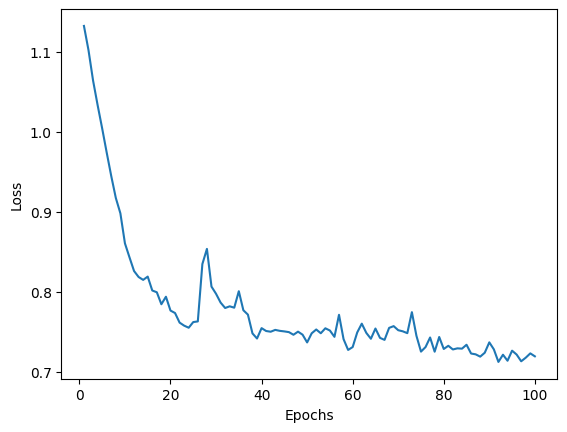

In [167]:
# Plot the loss over epochs to visualise how well the model is doing
epochs = list(range(1, 101))

print(running_loss_history)

plt.plot(epochs, running_loss_history)
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.show()